In [ ]:
# Customer Segmentation Analysis

## Objective
The goal of this project is to segment customers of an e-commerce platform
based on their demographic and purchasing behavior using K-Means clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("customer_segmentation_data.csv")

In [4]:
df.shape



(1000, 9)

In [5]:
df.columns


Index(['id', 'age', 'gender', 'income', 'spending_score', 'membership_years',
       'purchase_frequency', 'preferred_category', 'last_purchase_amount'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   age                   1000 non-null   int64  
 2   gender                1000 non-null   object 
 3   income                1000 non-null   int64  
 4   spending_score        1000 non-null   int64  
 5   membership_years      1000 non-null   int64  
 6   purchase_frequency    1000 non-null   int64  
 7   preferred_category    1000 non-null   object 
 8   last_purchase_amount  1000 non-null   float64
dtypes: float64(1), int64(6), object(2)
memory usage: 70.4+ KB


In [7]:
df.describe()


,id,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,43.783000,88500.800000,50.685000,5.46900,26.596000,492.348670
std,288.819436,15.042213,34230.771122,28.955175,2.85573,14.243654,295.744253
min,1.000000,18.000000,30004.000000,1.000000,1.00000,1.000000,10.400000
25%,250.750000,30.000000,57911.750000,26.000000,3.00000,15.000000,218.762500
50%,500.500000,45.000000,87845.500000,50.000000,5.00000,27.000000,491.595000
75%,750.250000,57.000000,116110.250000,76.000000,8.00000,39.000000,747.170000
max,1000.000000,69.000000,149973.000000,100.000000,10.00000,50.000000,999.740000


In [8]:
df.isnull().sum()

id                      0
age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64

In [9]:
df= df.drop("id", axis=1)

In [10]:
df = pd.get_dummies(df, drop_first=True)

In [11]:
df.head()


,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount,gender_Male,gender_Other,preferred_category_Electronics,preferred_category_Groceries,preferred_category_Home & Garden,preferred_category_Sports
0,38,99342,90,3,24,113.53,False,False,False,True,False,False
1,21,78852,60,2,42,41.93,False,False,False,False,False,True
2,60,126573,30,2,28,424.36,False,False,False,False,False,False
3,40,47099,74,9,5,991.93,False,True,False,False,True,False
4,65,140621,21,3,25,347.08,False,False,True,False,False,False


In [12]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [13]:
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df.head()

,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount,gender_Male,gender_Other,preferred_category_Electronics,preferred_category_Groceries,preferred_category_Home & Garden,preferred_category_Sports
0,-0.384644,0.316868,1.358468,-0.865010,-0.182348,-1.281540,-0.745124,-0.697054,-0.523341,2.006272,-0.509358,-0.515580
1,-1.515362,-0.282016,0.321865,-1.215358,1.082005,-1.523763,-0.745124,-0.697054,-0.523341,-0.498437,-0.509358,1.939563
2,1.078639,1.112778,-0.714738,-1.215358,0.098620,-0.230005,-0.745124,-0.697054,-0.523341,-0.498437,-0.509358,-0.515580
3,-0.251618,-1.210096,0.805613,1.237080,-1.516943,1.690080,-0.745124,1.434609,-0.523341,-0.498437,1.963255,-0.515580
4,1.411203,1.523374,-1.025718,-0.865010,-0.112106,-0.491443,-0.745124,-0.697054,1.910802,-0.498437,-0.509358,-0.515580


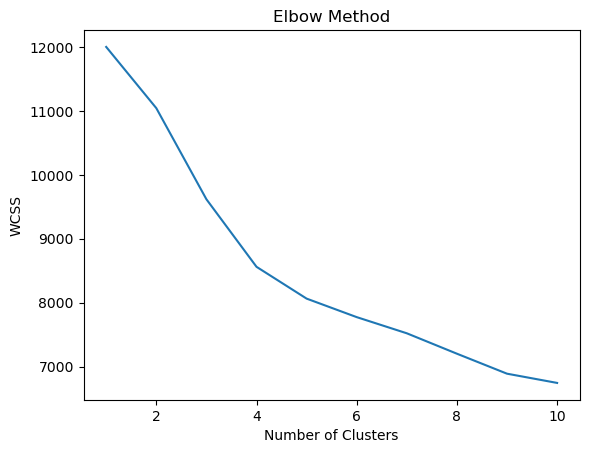

In [14]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [15]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_df)

In [16]:
df["Cluster"] = clusters
df.head()

,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount,gender_Male,gender_Other,preferred_category_Electronics,preferred_category_Groceries,preferred_category_Home & Garden,preferred_category_Sports,Cluster
0,38,99342,90,3,24,113.53,False,False,False,True,False,False,0
1,21,78852,60,2,42,41.93,False,False,False,False,False,True,1
2,60,126573,30,2,28,424.36,False,False,False,False,False,False,3
3,40,47099,74,9,5,991.93,False,True,False,False,True,False,3
4,65,140621,21,3,25,347.08,False,False,True,False,False,False,2


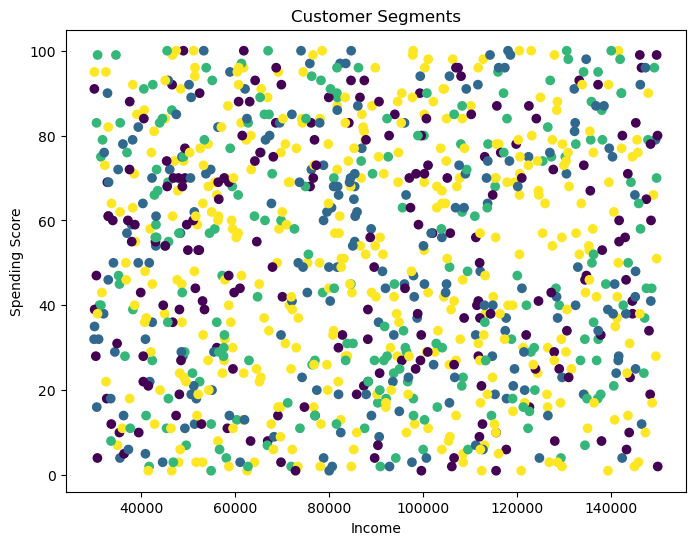

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["income"],
    df["spending_score"],
    c=df["Cluster"]
)

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

In [18]:
df.groupby("Cluster").mean()

,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount,gender_Male,gender_Other,preferred_category_Electronics,preferred_category_Groceries,preferred_category_Home & Garden,preferred_category_Sports
Cluster,,,,,,,,,,,,
0,43.793970,87691.371859,51.256281,5.321608,27.160804,487.279397,0.356784,0.311558,0.0,1.0,0.000000,0.0
1,44.104762,87563.195238,51.014286,5.480952,27.114286,481.953190,0.366667,0.342857,0.0,0.0,0.000000,1.0
2,43.079070,89111.339535,50.297674,5.804651,26.427907,496.632279,0.353488,0.344186,1.0,0.0,0.000000,0.0
3,44.000000,89103.744681,50.420213,5.348404,26.103723,498.388191,0.353723,0.316489,0.0,0.0,0.547872,0.0


In [ ]:
## Conclusion

In this project, customer segmentation was performed using K-Means clustering on an e-commerce dataset.
After data preprocessing, feature scaling, and optimal cluster selection using the Elbow Method,
four meaningful customer segments were identified.

The analysis provides actionable insights that can help businesses target customers more effectively,
optimize marketing strategies, and improve customer satisfaction.